In [117]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam
import tensorflow as tf
import numpy as np
import pandas as pd
import seaborn as sns

In [118]:
DATASETH_PATH = "Dataset_of_Heart.csv"
heart_data = pd.read_csv(DATASETH_PATH)

In [119]:
datos = heart_data.drop(columns=["target"])
etiquetas = heart_data["target"]

In [120]:
categorical_columns = datos.select_dtypes(include=['object']).columns
for col in categorical_columns:
    le = LabelEncoder()
    datos[col] = le.fit_transform(datos[col])

datos = datos.iloc[:, :13]

In [121]:
Y_onehot = tf.keras.utils.to_categorical(etiquetas)

x_train, x_test, y_train, y_test = train_test_split(datos, Y_onehot, test_size=0.25, stratify=etiquetas, shuffle=True)

In [122]:
datos.head()

,age,sex,cp,trtbps,chol,fbs,rest_ecg,thalachh,exng,oldpeak,slope,ca,thall
0,63,1,0,145,233,True,1,150,0,2.3,1,0,1
1,37,1,1,130,250,False,2,187,0,3.5,2,0,2
2,41,0,3,130,204,False,1,172,0,1.4,1,0,2
3,56,1,3,120,236,False,2,178,0,0.8,1,0,2
4,57,0,2,120,354,False,2,163,1,0.6,1,0,2


In [ ]:
model = tf.keras.models.Sequential()
model.add(Input(shape=(13,)))
model.add(Dense(64, activation = "relu"))
model.add(Dropout(.2))
model.add(Dense(32, activation = "relu"))
model.add(Dropout(.2))
model.add(Dense(units = 2, activation = 'softmax'))

In [124]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

heart_model = model.fit(x_train, y_train, epochs=200, batch_size=7, validation_data=(x_test, y_test))

Epoch 1/200
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.5330 - loss: 21.0217 - val_accuracy: 0.5395 - val_loss: 3.3998
Epoch 2/200
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5066 - loss: 11.0594 - val_accuracy: 0.6184 - val_loss: 1.6224
Epoch 3/200
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5022 - loss: 6.4363 - val_accuracy: 0.5395 - val_loss: 4.4627
Epoch 4/200
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5022 - loss: 6.2585 - val_accuracy: 0.6974 - val_loss: 0.6575
Epoch 5/200
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5683 - loss: 3.9319 - val_accuracy: 0.5921 - val_loss: 1.1922
Epoch 6/200
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5286 - loss: 3.1600 - val_accuracy: 0.6316 - val_loss: 0.7971
Epoch 7/200
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5551 - loss: 2.4900 - val_accuracy: 0.6711 - val_loss: 0.6004
Epoch 8/200
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5771 - loss: 2.2186 - val_accuracy: 0.6447 

In [131]:
heart_model.history

{'accuracy': [0.5330396294593811,
  0.5066079497337341,
  0.5022026300430298,
  0.5022026300430298,
  0.5682819485664368,
  0.5286343693733215,
  0.5550661087036133,
  0.5770925283432007,
  0.5814977884292603,
  0.5859031081199646,
  0.5638766288757324,
  0.5198237895965576,
  0.5066079497337341,
  0.5638766288757324,
  0.541850209236145,
  0.5462555289268494,
  0.48458150029182434,
  0.5022026300430298,
  0.5110132098197937,
  0.5242290496826172,
  0.4889867901802063,
  0.5242290496826172,
  0.5506607890129089,
  0.6123347878456116,
  0.5770925283432007,
  0.5991189479827881,
  0.5198237895965576,
  0.607929527759552,
  0.5682819485664368,
  0.5330396294593811,
  0.5682819485664368,
  0.541850209236145,
  0.5682819485664368,
  0.5550661087036133,
  0.5726872086524963,
  0.6255506873130798,
  0.5814977884292603,
  0.5903083682060242,
  0.5242290496826172,
  0.5330396294593811,
  0.5991189479827881,
  0.5903083682060242,
  0.5770925283432007,
  0.5550661087036133,
  0.5374449491500854,


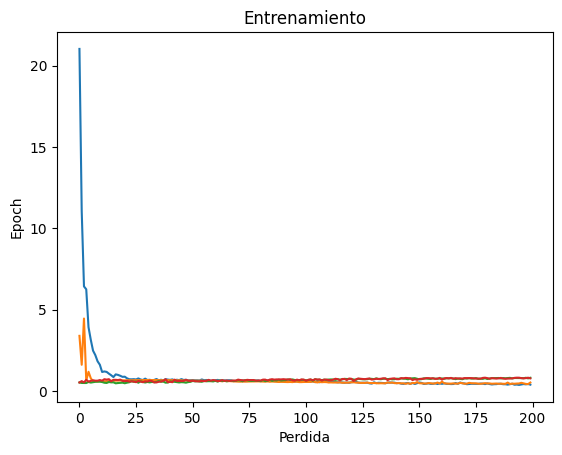

In [ ]:
plt.figure()
plt.plot(heart_model.epoch, heart_model.history['loss'])
plt.plot(heart_model.epoch, heart_model.history['val_loss'])
plt.xlabel("Perdida")
plt.ylabel("Epoch")
plt.title("Entrenamiento")
plt.show()


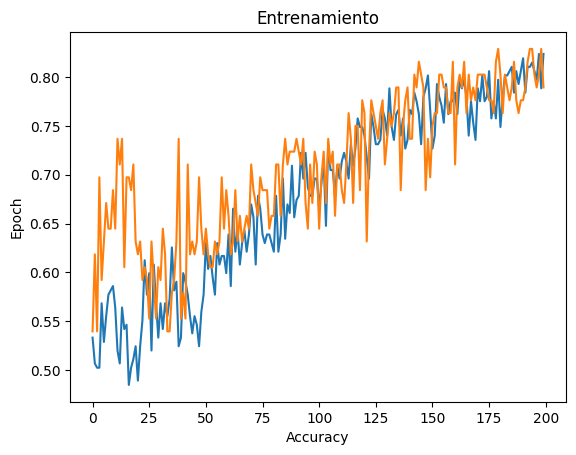

In [135]:
plt.figure()
plt.plot(heart_model.epoch, heart_model.history['accuracy'])
plt.plot(heart_model.epoch, heart_model.history['val_accuracy'])
plt.xlabel("Accuracy")
plt.ylabel("Epoch")
plt.title("Entrenamiento")
plt.show()

In [128]:
model.evaluate(x_test, y_test)

predictions = model.predict(x_test)
predictions = np.argmax(predictions, axis=1)
real_y = np.argmax(y_test, axis=1)
predictions

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7895 - loss: 0.5319
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


array([0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0,
       1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0,
       1, 0, 1, 1, 1, 0, 1, 0, 1, 1])

In [129]:
real_y

array([0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1,
       1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1,
       1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0,
       0, 0, 1, 0, 1, 0, 1, 0, 1, 1])

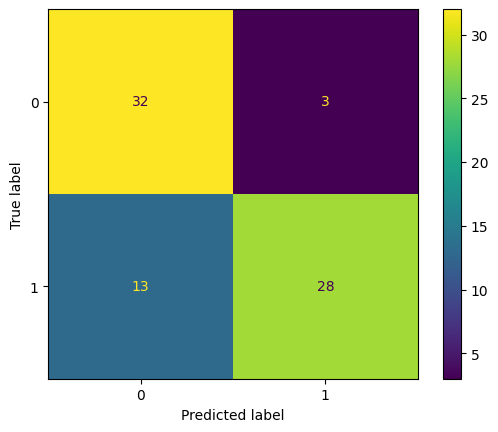

In [130]:
cm = confusion_matrix(real_y, predictions,)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=np.unique(real_y) )
disp.plot()
plt.show()